In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Books_Data_Clean.csv')

In [4]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [9]:
df.describe().T  ## here T is refers for transpose

,count,mean,std,min,25%,50%,75%,max
index,879.0,538.514221,304.154030,0.00,281.50,538.000,800.500,1069.00
Publishing Year,879.0,2002.321957,10.538026,1971.00,1997.00,2005.000,2011.000,2016.00
Book_average_rating,879.0,4.010137,0.252236,2.97,3.85,4.020,4.180,4.77
Book_ratings_count,879.0,93943.406143,30830.853363,27308.00,70255.00,88626.000,111723.500,206792.00
gross sales,879.0,1781.571934,3949.121774,104.94,355.81,784.160,1428.320,47795.00
publisher revenue,879.0,815.450444,2265.606391,0.00,0.00,268.128,716.658,28677.00
sale price,879.0,4.821843,3.481087,0.99,1.99,3.990,6.990,25.89
sales rank,879.0,616.097838,364.208405,1.00,304.00,600.000,930.500,1273.00
units sold,879.0,9955.802048,15468.224969,106.00,597.50,4000.000,5454.000,61560.00


In [10]:
df = df[df['Publishing Year']> 1970]

In [14]:
df.isna().sum()

index                   0
Publishing Year         0
Book Name               0
Author                  0
language_code          38
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

In [13]:
## we perform the sales analysis on book if books name is null that what is the point to include
df.dropna(subset='Book Name', inplace=True)

In [16]:
df.duplicated().sum()  ## there is no duplicte values 

np.int64(0)

In [18]:
df.nunique()

index                  860
Publishing Year         46
Book Name              859
Author                 559
language_code            8
Author_Rating            4
Book_average_rating    131
Book_ratings_count     857
genre                    4
gross sales            678
publisher revenue      498
sale price             126
sales rank             732
Publisher                9
units sold             435
dtype: int64

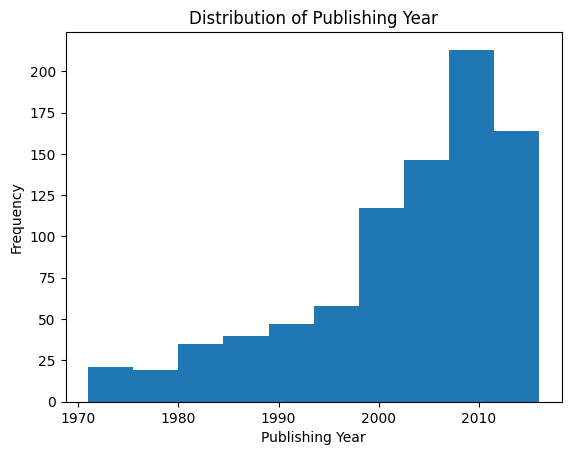

In [20]:
plt.hist(df['Publishing Year'])
plt.xlabel('Publishing Year')
plt.ylabel('Frequency')
plt.title('Distribution of Publishing Year')
plt.show()

Text(0.5, 1.0, 'Number of Books in Each Genre')

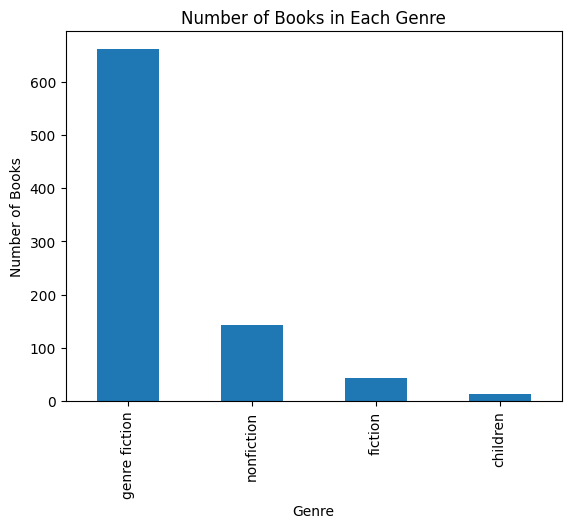

In [24]:
df['genre'].value_counts().plot(kind='bar')
plt.xlabel('Genre')
plt.ylabel('Number of Books')
plt.title('Number of Books in Each Genre')

In [29]:
df.groupby('Author')['Book_average_rating'].mean().sort_values(ascending=False)

Author
Bill Watterson                  4.650000
Bill Watterson, G.B. Trudeau    4.610000
J.R.R. Tolkien                  4.590000
George R.R. Martin              4.560000
Sarah J. Maas                   4.526000
                                  ...   
Chetan Bhagat                   3.273333
Audrey Niffenegger              3.230000
Herman Koch, Sam Garrett        3.220000
P.D. James                      3.210000
Sue Monk Kidd                   3.100000
Name: Book_average_rating, Length: 559, dtype: float64

Text(0.5, 1.0, 'Box Plot of Book Rating Count for Each Genre')

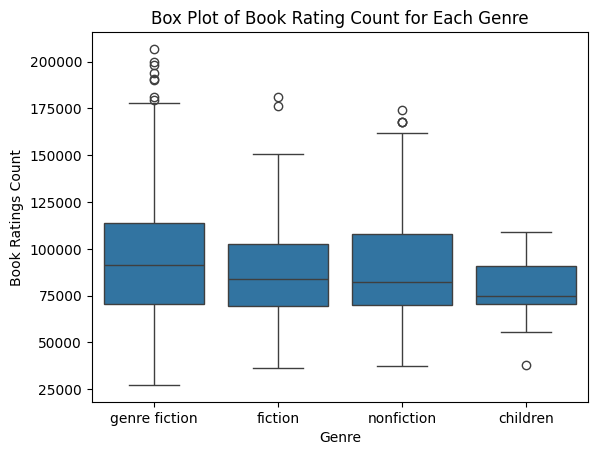

In [34]:
sns.boxplot(x='genre', y='Book_ratings_count', data=df)
plt.xlabel('Genre')
plt.ylabel('Book Ratings Count')
plt.title('Box Plot of Book Rating Count for Each Genre')

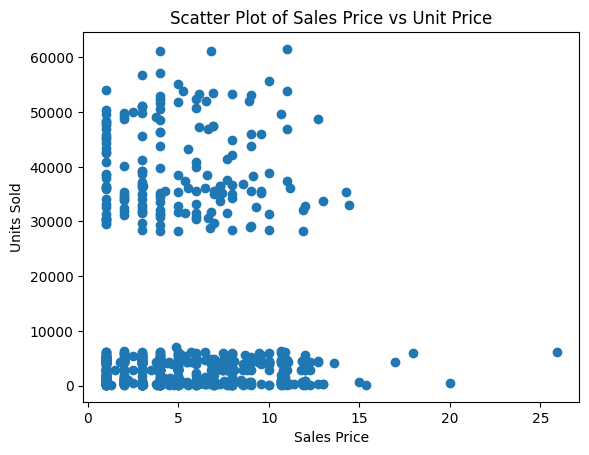

In [36]:
plt.scatter(df['sale price'], df['units sold'])
plt.xlabel('Sales Price')
plt.ylabel('Units Sold')
plt.title('Scatter Plot of Sales Price vs Unit Price')
plt.show()

In [39]:
language_count = df['language_code'].value_counts().sort_values(ascending=True)  

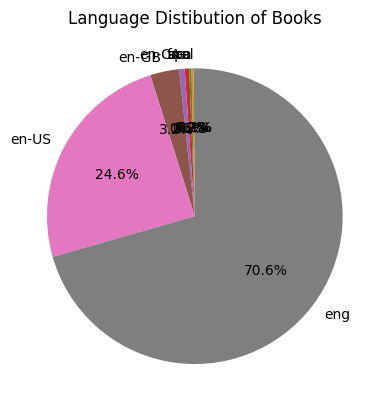

In [44]:
plt.pie(language_count, labels=language_count.index,  startangle=90, autopct='%1.1f%%')
plt.title('Language Distibution of Books')
plt.show()

In [52]:
df.columns

Index(['index', 'Publishing Year', 'Book Name', 'Author', 'language_code',
       'Author_Rating', 'Book_average_rating', 'Book_ratings_count', 'genre',
       'gross sales', 'publisher revenue', 'sale price', 'sales rank',
       'Publisher ', 'units sold'],
      dtype='object')

In [ ]:
# There is space in names of columns need to remove 
## In python there is a funciton strim that remove space ( strip() )

In [57]:
df.columns = df.columns.str.strip()
df.columns

Index(['index', 'Publishing Year', 'Book Name', 'Author', 'language_code',
       'Author_Rating', 'Book_average_rating', 'Book_ratings_count', 'genre',
       'gross sales', 'publisher revenue', 'sale price', 'sales rank',
       'Publisher', 'units sold'],
      dtype='object')

In [59]:
df.groupby('Publisher')['publisher revenue'].sum().sort_values(ascending=False)

Publisher
Penguin Group (USA) LLC                 151613.970
Random House LLC                        136448.142
Amazon Digital Services,  Inc.          130002.294
HarperCollins Publishers                113730.942
Hachette Book Group                      83753.430
Simon and Schuster Digital Sales Inc     41218.692
Macmillan                                27800.478
HarperCollins Publishing                  2429.262
HarperCollins Christian Publishing        2135.670
Name: publisher revenue, dtype: float64

In [60]:
df.groupby('Author_Rating')['Book_ratings_count'].mean().sort_values(ascending=False).max()

np.float64(99384.4251497006)

In [65]:
df.groupby('language_code').size().sort_values(ascending=False) 

language_code
eng      580
en-US    202
en-GB     26
en-CA      5
fre        4
ara        2
spa        2
nl         1
dtype: int64

In [67]:
df.groupby('Author_Rating')['Book_ratings_count'].var()

Author_Rating
Excellent       4.736074e+08
Famous          1.258625e+09
Intermediate    1.103109e+09
Novice          8.818740e+08
Name: Book_ratings_count, dtype: float64

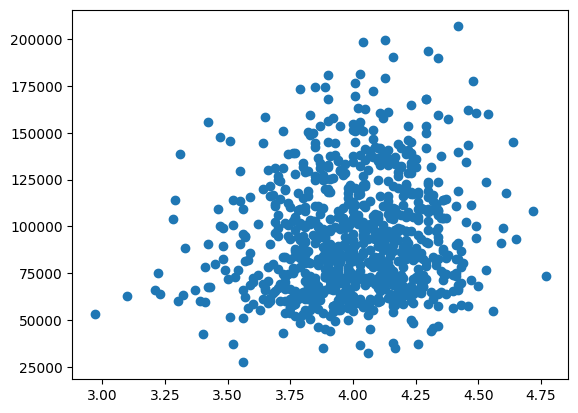

In [71]:
plt.scatter(df['Book_average_rating'], df['Book_ratings_count'])
plt.show()

In [75]:
total_gross_sales_by_author = df.groupby('Author')['gross sales'].sum()


<Axes: xlabel='Author'>

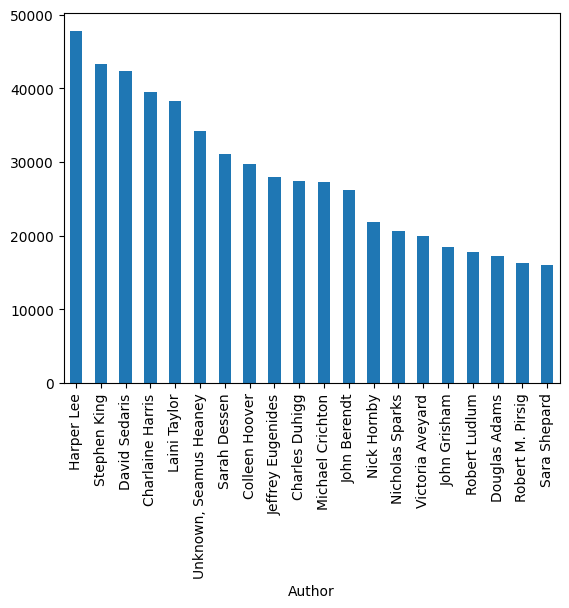

In [77]:
total_gross_sales_by_author.sort_values(ascending=False).head(20).plot(kind='bar')

<Axes: xlabel='Author_Rating', ylabel='units sold'>

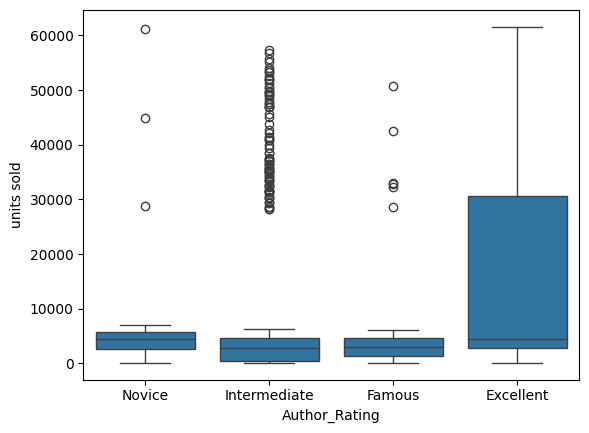

In [80]:
sns.boxplot(x='Author_Rating',y='units sold',data=df)

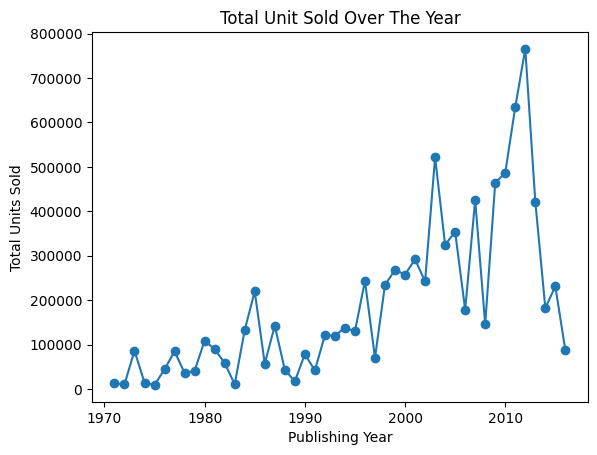

In [86]:
df.groupby('Publishing Year')['units sold'].sum().plot(kind='line',marker ='o')
plt.xlabel('Publishing Year')
plt.ylabel('Total Units Sold')
plt.title('Total Unit Sold Over The Year')
plt.show()